# Train, test, and evaluate the churn model

This notebook calls the same reproducible training code used by `backend/train_model.py`. It selects XGBoost settings using 5-fold stratified cross-validation on the training split, selects a probability threshold on validation data, then evaluates once on the untouched test split.

The exported pipeline preserves the API's required `pre` and `clf` steps. Test metrics and bootstrap confidence intervals are written to `reports/metrics/model_evaluation.json`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'backend'))

from train_model import train_and_evaluate, load_and_clean_data, FEATURES
from app.ml.explainer import ChurnExplainer

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\churnxai


In [2]:
results = train_and_evaluate(
    data_path=PROJECT_ROOT / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv',
    model_dir=PROJECT_ROOT / 'backend' / 'models',
    processed_path=PROJECT_ROOT / 'data' / 'processed' / 'telco_clean.csv',
    figures_dir=PROJECT_ROOT / 'reports' / 'figures',
    metrics_path=PROJECT_ROOT / 'reports' / 'metrics' / 'model_evaluation.json',
    random_state=42,
    n_bootstrap=2000,
)
metadata = results['metadata']
print(f"Saved real model: {results['model_path']}")
print(f"Validation-selected threshold: {metadata['decision_threshold']:.3f}")

Saved real model: d:\churnxai\backend\models\xgb_churn_pipeline.joblib
Validation-selected threshold: 0.605


In [7]:
metric_names = [

    'average_precision', 'roc_auc', 'accuracy', 'balanced_accuracy',

    'precision', 'recall', 'f1', 'brier_score',

]

ci_keys = {'average_precision': 'pr_auc', 'roc_auc': 'roc_auc', 'f1': 'f1'}

test_metrics = metadata['test_metrics']

intervals = metadata['test_metrics_95ci']

metrics_table = pd.DataFrame({

    'test_value': {name: test_metrics[name] for name in metric_names},

    '95% bootstrap CI': {

        name: (

            f"[{intervals[ci_keys[name]]['ci_low']:.3f}, {intervals[ci_keys[name]]['ci_high']:.3f}]"

            if name in ci_keys and ci_keys[name] in intervals

            else 'Not calculated'

        )

        for name in metric_names

    },

})

display(metrics_table)

display(metadata['selection'])

display(metadata['split_rows'])

display(test_metrics['confusion_matrix'])

,test_value,95% bootstrap CI
average_precision,0.660559,"[0.607, 0.709]"
roc_auc,0.843774,"[0.820, 0.865]"
accuracy,0.775727,Not calculated
balanced_accuracy,0.749155,Not calculated
precision,0.563043,Not calculated
recall,0.692513,Not calculated
f1,0.621103,"[0.579, 0.657]"
brier_score,0.162841,Not calculated


{'method': '5-fold stratified cross-validation; average precision (PR-AUC)',
 'best_cv_average_precision': 0.6692393229058137,
 'best_params': {'clf__learning_rate': 0.05,
  'clf__max_depth': 3,
  'clf__n_estimators': 200}}

{'train': 4225,
 'validation': 1409,
 'train_plus_validation': 5634,
 'test': 1409}

{'true_negative': 834,
 'false_positive': 201,
 'false_negative': 115,
 'true_positive': 259}

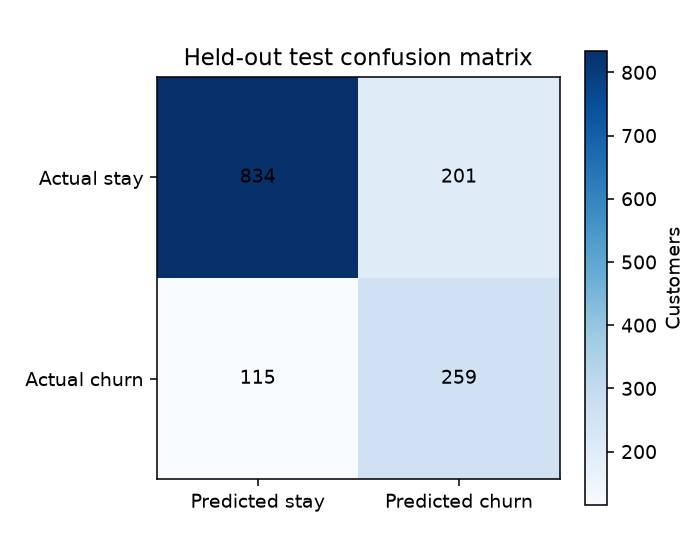

In [5]:
confusion = test_metrics['confusion_matrix']

matrix = [[confusion['true_negative'], confusion['false_positive']],

          [confusion['false_negative'], confusion['true_positive']]]

fig, ax = plt.subplots(figsize=(5, 4))

image = ax.imshow(matrix, cmap='Blues')

ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Predicted stay', 'Predicted churn'],

       yticklabels=['Actual stay', 'Actual churn'], title='Held-out test confusion matrix')

for row in range(2):

    for column in range(2):

        ax.text(column, row, matrix[row][column], ha='center', va='center', color='black')

fig.colorbar(image, ax=ax, label='Customers')

fig.tight_layout()

confusion_path = PROJECT_ROOT / 'reports' / 'figures' / 'test_confusion_matrix.png'

confusion_path.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(confusion_path, dpi=140)

plt.close(fig)

display(Image(filename=str(confusion_path)))

[01:02:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
2026-10-05 01:02:46.650 | INFO     | app.ml.explainer:__init__:53 - ✅ SHAP TreeExplainer initialized. Base value (log-odds): 0.0000
2026-10-05 01:02:46.653 | INFO     | app.ml.explainer:__init__:54 - 📊 Explainer mapped to 46 features.
2026-10-05 01:02:47.448 | INFO     | app.utils.timing:wrapper:21 - explain executed in 0.793s


Example churn probability: 0.564


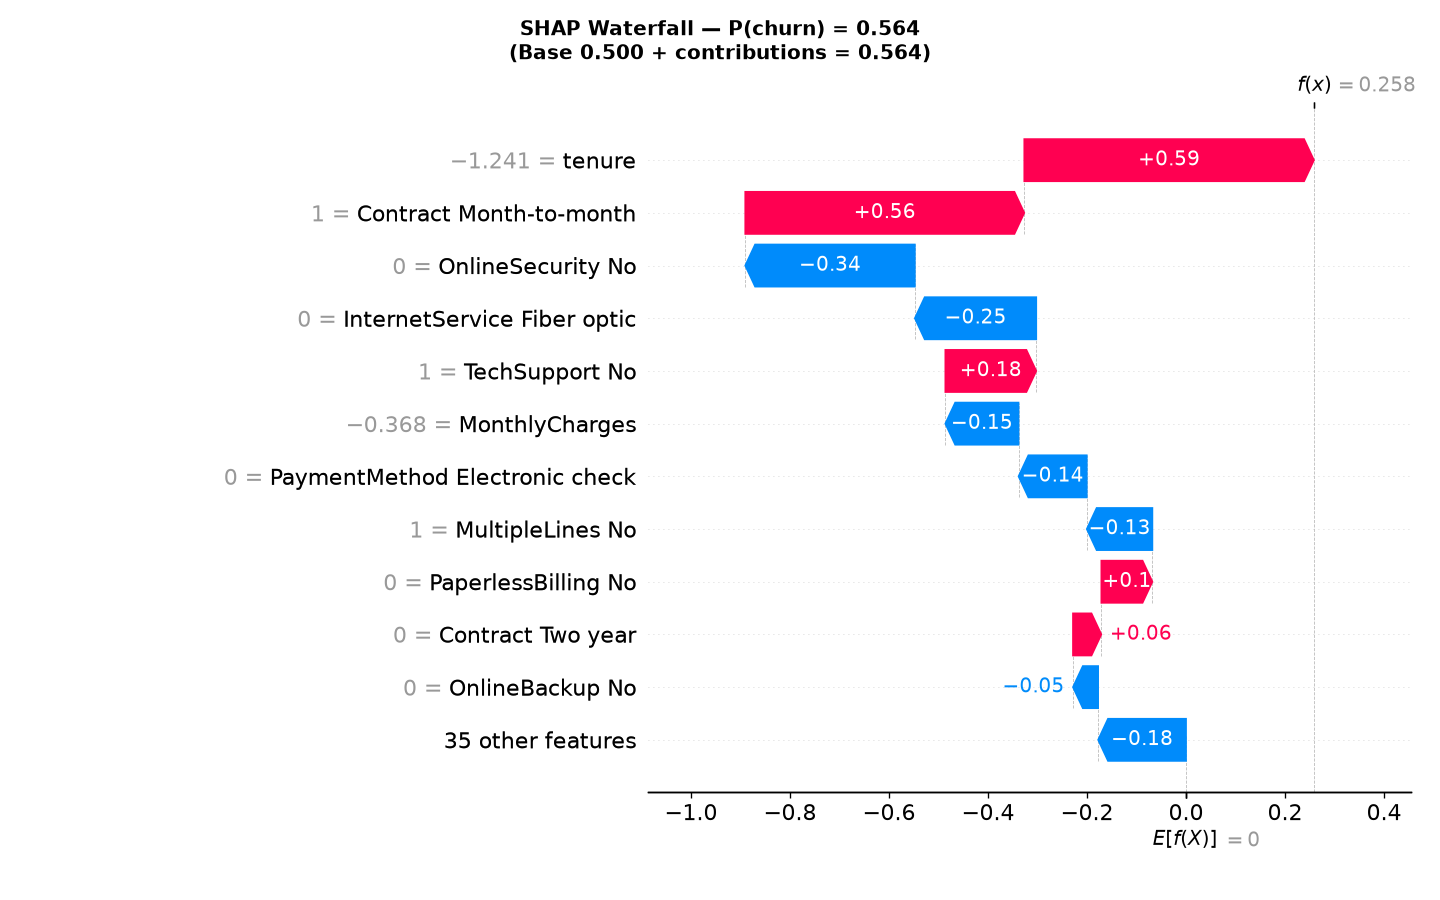

In [6]:
cleaned, _ = load_and_clean_data(PROJECT_ROOT / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
pipeline = __import__('joblib').load(results['model_path'])
sample = cleaned[FEATURES].iloc[2].to_dict()
local_explanation = ChurnExplainer(pipeline, metadata).explain(sample)
print(f"Example churn probability: {local_explanation['churn_probability']:.3f}")
display(Image(data=__import__('base64').b64decode(local_explanation['waterfall_image_base64'])))